In [24]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
qubit_counts = [2,3,4,5,6,7,8,10]
n_qubits = 12
n_layers = 2
n_trials = 200

In [26]:
def create_circuit(n_qubits, n_layers):

    dev = qml.device("lightning.gpu",wires = n_qubits, c_dtype=np.complex64)

    @qml.qnode(dev, diff_method="adjoint")
    def circuit(weights):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(weights[layer, q],wires=q)

            for q in range(n_qubits-1):
                qml.CNOT(wires=[q,q + 1])

        return qml.expval(qml.PauliZ(0))
    return circuit

In [27]:
circuit = create_circuit(n_qubits, n_layers)

weights =  np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits))

epsilon = 1e-3

weights_plus = weights.copy()
weights_plus[0,0] += epsilon
        
cost_plus = circuit(weights_plus)
        
weights_minus = weights.copy()
weights_minus[0,0] -= epsilon
        
cost_minus = circuit(weights_minus)
        
gradient = (cost_plus - cost_minus) / (2*epsilon)
#0.5 * 9et rid of 2*epsilon
#make epsilon into np.pi/2
print("Weights shape:",weights.shape)
print("Cost +",cost_plus)
print("Cost -",cost_minus)
print(gradient)

Weights shape: (2, 12)
Cost + -0.8032175898551941
Cost - -0.8036733865737915
0.22789835929870605


In [28]:
def run_single_gradient_experiment(n_qubits, n_layers, n_trials):

    circuit = create_circuit(n_qubits,n_layers)
    
    all_gradients = []

    shift = np.pi / 2
    
    for trial in range(n_trials):
        
        
        weights_plus = weights.copy()
        weights_plus[0,0] += shift
        
        cost_plus = circuit(weights_plus)
        
        weights_minus = weights.copy()
        weights_minus[0,0] -= shift
        
        cost_minus = circuit(weights_minus)
        
        gradient = 0.5 * (cost_plus - cost_minus) 
        
        all_gradients.append(gradient)
        
   # qml.draw_mpl(circuit,style='pennylane')(weights);
    
    return np.array(all_gradients)

In [29]:
gradients = run_single_gradient_experiment(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)

In [30]:
results = []

for n_qubits in qubit_counts:

    print(f"Running {n_qubits} qubits...")

    gradients = run_single_gradient_experiment(n_qubits=n_qubits, n_layers=n_layers,n_trials=n_trials)

    mean_gradient = np.mean(gradients)
    variance = np.var(gradients)

    results.append({"Qubits": n_qubits,"Variance": variance,"Mean Gradient": mean_gradient})

    print(f"Mean = {mean_gradient:.6e}, "f"Variance = {variance}")

    results_df = pd.DataFrame(results)

    display(results_df)

Running 2 qubits...
Mean = 2.279100e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.22791001200675964


Running 3 qubits...
Mean = 2.279100e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.22791001200675964
1,3,0.0,0.22790997475385666


Running 4 qubits...
Mean = 2.279099e-01, Variance = 0.0


...

,Qubits,Variance,Mean Gradient
0,2,0.0,0.22791001200675964
1,3,0.0,0.22790997475385666
2,4,0.0,0.2279099002480507
3,5,0.0,0.22791007906198502
4,6,0.0,0.22791005671024323
5,7,0.0,0.22791004925966263


Running 8 qubits...
Mean = 2.279100e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.22791001200675964
1,3,0.0,0.22790997475385666
2,4,0.0,0.2279099002480507
3,5,0.0,0.22791007906198502
4,6,0.0,0.22791005671024323
5,7,0.0,0.22791004925966263
6,8,0.0,0.22791003435850143


Running 10 qubits...
Mean = 2.279100e-01, Variance = 0.0


,Qubits,Variance,Mean Gradient
0,2,0.0,0.22791001200675964
1,3,0.0,0.22790997475385666
2,4,0.0,0.2279099002480507
3,5,0.0,0.22791007906198502
4,6,0.0,0.22791005671024323
5,7,0.0,0.22791004925966263
6,8,0.0,0.22791003435850143
7,10,0.0,0.22791004180908203


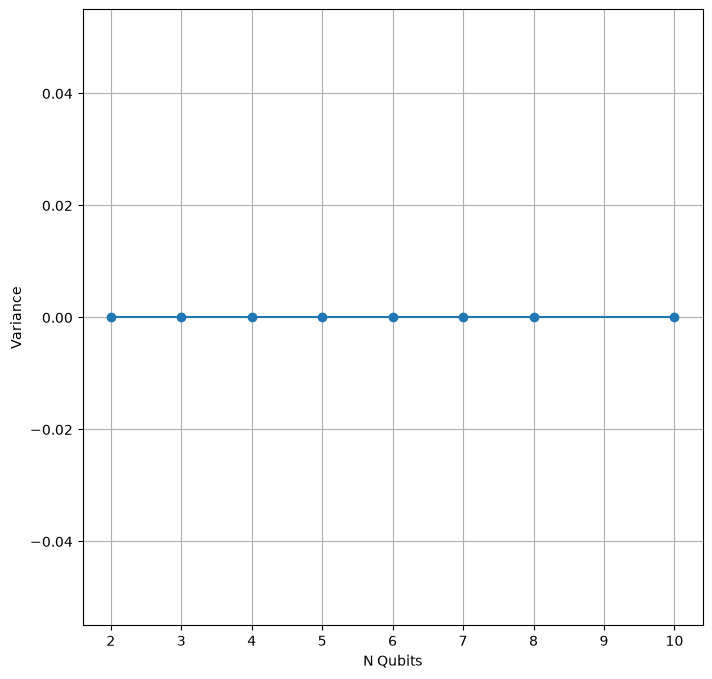

In [31]:
qubits = np.array([r["Qubits"] for r in results])
variances = np.array([r["Variance"] for r in results])

plt.figure(figsize=(8,len(qubit_counts)))

plt.plot(qubits,variances,marker="o")
#plt.yscale("log")

plt.xlabel("N Qubits")
plt.ylabel("Variance")

plt.grid(True)
plt.show()